In [1]:
# -----------------------------------
# LIBRERIAS
# -----------------------------------

# Tratamiento de datos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración Gráficas
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = [6, 4.5]
palette = ["#003049","#d62828","#f77f00","#fcbf49","#eae2b7"]
sns.set_theme( palette= palette, context= "notebook")

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# -----------------------------------
# CARGUE DE DATOS
# -----------------------------------

data = pd.read_csv("Car_details_v4.csv")

In [3]:
# -----------------------------------
# INFORMACIÓN DEL DATASET
# -----------------------------------

# Número de filas y columnas:
data.shape

(2059, 20)

In [4]:
# Valores faltantes en las variables:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [5]:
# Principales medidas de tendencia central:
data.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [6]:
# -----------------------------------
# TRATAMIENTO DE VALORES FALTANTES
# -----------------------------------

# Cantidad de valores faltantes por variable:
data.isna().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [7]:
# Vemos que 9 variables tienen campos faltantes

In [8]:
# Vamos a observar cuántos registros tienen al menos un dato nulo:

data[data.isnull().any(axis=1)]

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
6,Mercedes-Benz,CLA 200 Petrol Sport,1898999,2015,47000,Petrol,Automatic,Mumbai,White,Second,Individual,1991 cc,181 bhp @ 5500 rpm,300 Nm @ 1200 rpm,FWD,4630.0,1777.0,1432.0,5.0,NaN
33,Honda,CR-V 2.4 AT,860000,2013,67000,Petrol,Automatic,Mumbai,Brown,First,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,Audi,A4 2.0 TDI (143 bhp),1250000,2012,50000,Diesel,Automatic,Mumbai,White,First,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,BMW,X5 xDrive30d Pure Experience (5 Seater),2950000,2015,84700,Diesel,Automatic,Navi Mumbai,Black,Second,Individual,2993 cc,258 bhp @ 4000 rpm,560 Nm @ 1500 rpm,AWD,4886.0,1938.0,1762.0,5.0,NaN
94,Mercedes-Benz,GLC 220 d Sport,3900000,2018,83400,Diesel,Automatic,Hyderabad,White,Second,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,Honda,Accord 2.4 iVtec AT,195000,2008,57885,Petrol,Automatic,Delhi,Beige,First,Individual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2032,Land Rover,Range Rover Velar 2.0 S Petrol 250,8900000,2020,88000,Petrol,Automatic,Mumbai,White,First,Individual,1997 cc,247 bhp @ 5500 rpm,365 Nm @ 1500 rpm,AWD,4797.0,2032.0,1665.0,5.0,NaN
2035,Maruti Suzuki,Wagon R LXi,265000,2011,41000,Petrol,Manual,Pune,Brown,Second,Individual,998 cc,68@6200,90@3500,NaN,3539.0,1475.0,1700.0,5.0,35.0
2052,Hyundai,i20 Sportz 1.4 CRDI,409999,2014,68000,Diesel,Manual,Agra,Silver,First,Individual,1396 cc,90@4000,220@1750,NaN,3940.0,1710.0,1505.0,5.0,45.0


In [9]:
# Vemos que hay 185 registros (filas) que al menos tienen un dato nulo. Ahora vamos a realizar el tratamiento de valores nulos. 

In [10]:
# Imputación de valores faltantes con la moda:
mode_columns = ["Engine", "Max Power", "Max Torque", "Drivetrain", "Length", "Width", "Height", "Seating Capacity"]

for col in mode_columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

# Imputación de valores faltantes con la mediana:
data['Fuel Tank Capacity'].fillna(data['Fuel Tank Capacity'].median(), inplace=True)

# Verificar nuevamente valores faltantes en el dataset:
data.info()
data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              2059 non-null   object 
 12  Max Power           2059 non-null   object 
 13  Max Torque          2059 non-null   object 
 14  Drivetrain          2059 non-null   object 
 15  Length              2059 non-null   float64
 16  Width 

Make                  0
Model                 0
Price                 0
Year                  0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
dtype: int64

In [11]:
# Vemos que ya no hay registros nulos

In [12]:
# -----------------------------------
# TRANSFORMACIÓN DE CARACTERÍSTICAS
# -----------------------------------

# Campo Engine

# Creamos una copia del Dataframe:
data_copia = data.copy()

# Separamos el valor del string: 
data_copia[["valor", "unidad"]] = data_copia["Engine"].str.split(" ", expand= True)

# Realizamos un conteo de las variables en la columna "unidad" Generada y mostramos el DataFrame: 
print(data_copia["unidad"].value_counts())

unidad
cc    2059
Name: count, dtype: int64


In [13]:
# En este caso, podemos notar que todos los datos tienen la misma unidad de medida, lo que nos permite eliminar la unidad de medida de los valores individuales. Dado que la unidad de medida es consistente para todo el campo, podemos optar por agregar la unidad de medida al encabezado (header) del campo para indicar claramente la unidad utilizada en todos los valores.

In [14]:
# Transformación del campo Engine: 
data["Engine"] = data["Engine"].str.extract("(\d+\.\d+|\d+)").astype(np.float64)

In [15]:
# Para el campo Max Power, podemos notar que los datos tienen 2 unidades de  medida: La potencia máxima de un carro se especifica típicamente en Brake Horsepower (bhp) o, en algunos casos, simplemente Horsepower (hp), junto con las revoluciones por minuto (rpm) a las cuales se alcanza esa potencia máxima. Esto puede representar una dificultad para el análisis posterior de los datos. Para este caso, se decide que la unidadd de medida más diciente de la potencia máxima es bhp, ya que este valor es una medida de la potencia real que el motor entrega al cigüeñal. Teniendo esto en cuenta, podemos eliminar de los datos las medidas de rpm, manteniendo solo la bhp y, posteriormente, se elimina la unidad de medida de los valores individuales. Dado que la unidad de medida es consistente para todo el campo, podemos optar por agregar la unidad de medida al encabezado (header) del campo para indicar claramente la unidad utilizada en todos los valores.

In [16]:
#Transformación del campo Max Power: 
data["Max Power"] = data["Max Power"].str.extract("(\d+\.\d+|\d+)").astype(np.float64)

In [17]:
#Renombramos las columnas Max Power y Engine:
data.rename(columns = {"Max Power": "Max Power (bhp)", "Engine": "Engine (cc)"}).head(6)

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine (cc),Max Power (bhp),Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198.0,87.0,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248.0,74.0,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197.0,79.0,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197.0,82.0,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393.0,148.0,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0
5,Maruti Suzuki,Ciaz ZXi,675000,2017,73315,Petrol,Manual,Pune,Grey,First,Individual,1373.0,91.0,130 Nm @ 4000 rpm,FWD,4490.0,1730.0,1485.0,5.0,43.0


In [18]:
# Eliminación de variables categóricas

#Eliminamos los campos Make, Model, Location, Max Torque. Estos campos se eliminan ya que tienen un alto número de variables cualitativas únicas, por lo que podría aumentar considerablemente la complejidad del modelo sin agregar un valor predictivo realmente significativo. 
data = data.drop(columns=['Make', 'Model', 'Location', 'Max Torque'])

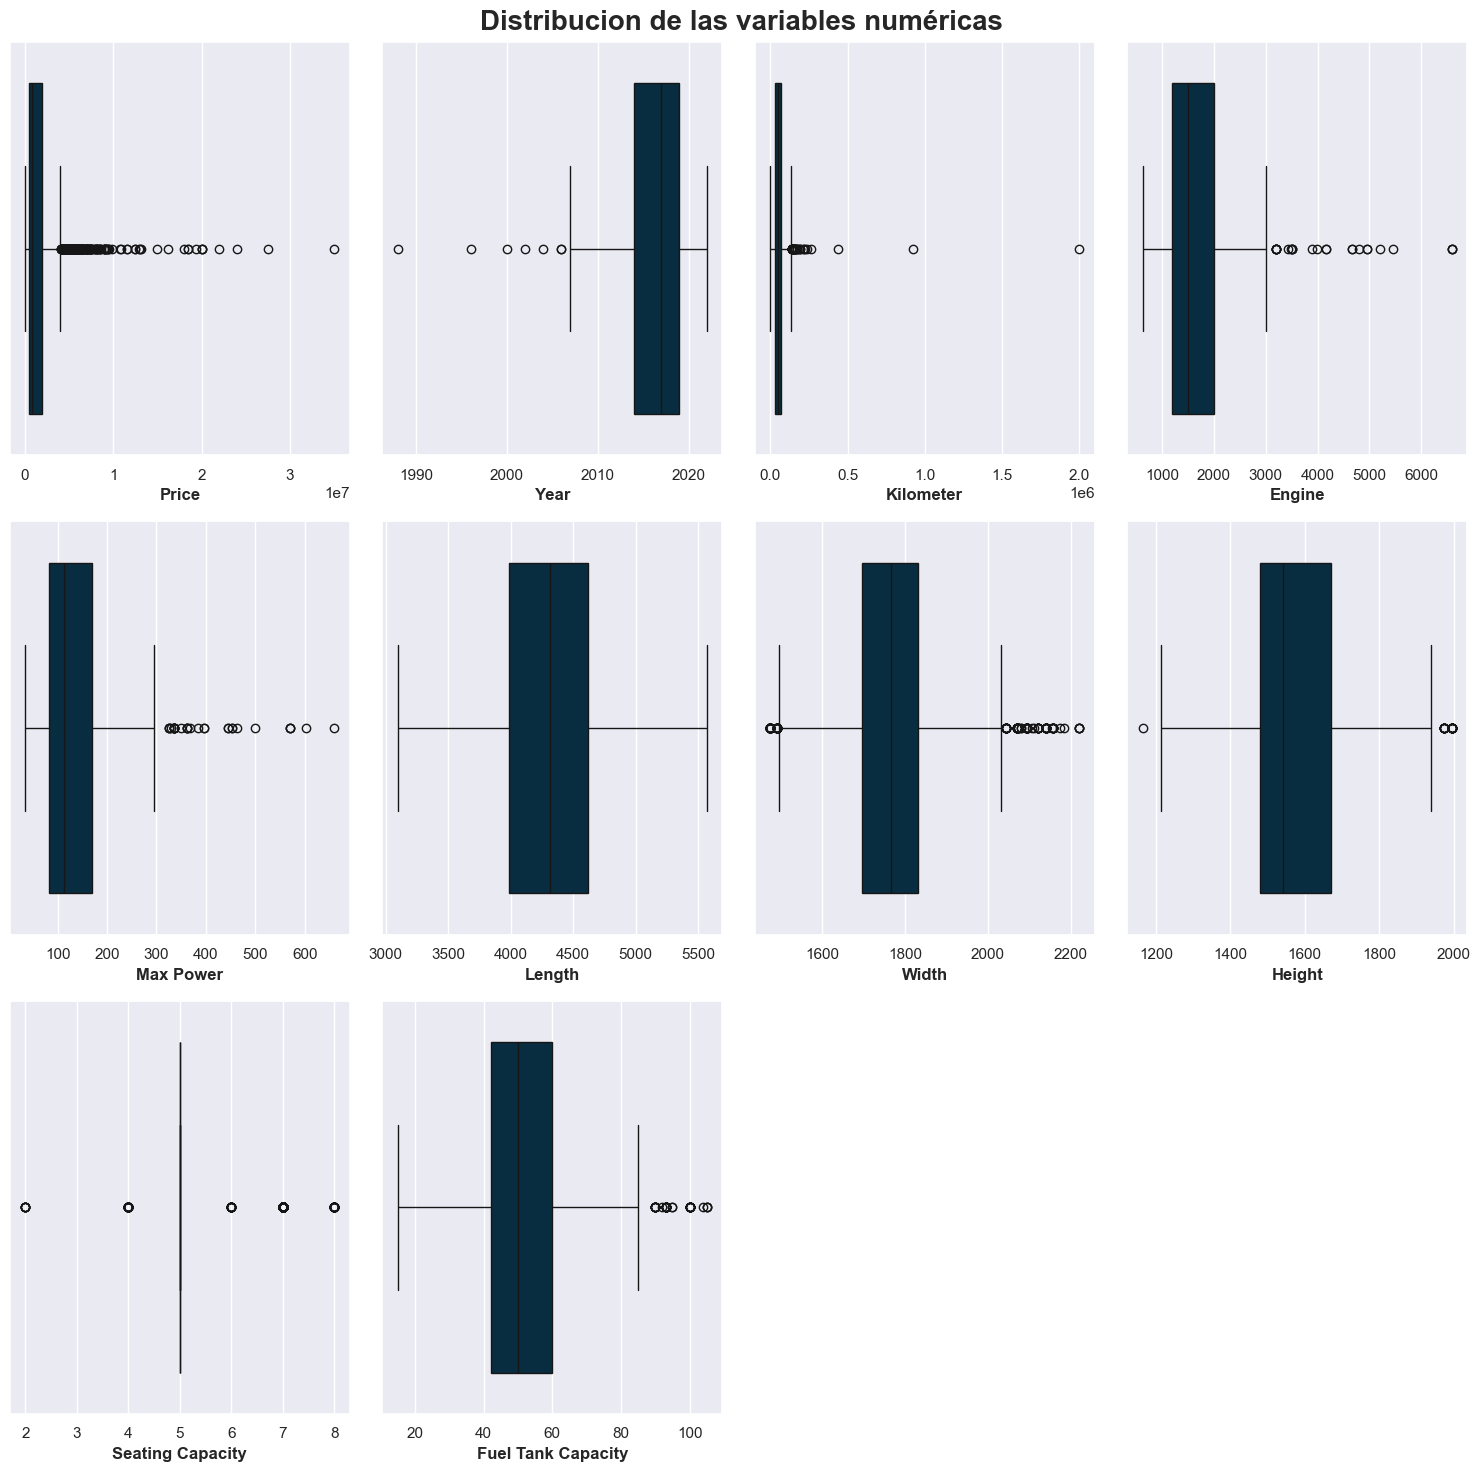

In [19]:
# -----------------------------------
# TRATAMIENTO DE VALORES ATÍPICOS
# -----------------------------------

# A continuación vamos a crear las gráficas de caja para observar la distribución de las variables numéricas:

caracteristicas = data.select_dtypes(include=[np.number]).columns
num_caracteristicas = len(caracteristicas)
num_filas = (num_caracteristicas + 3) // 4  # Calcula el número de filas necesarias (redondeo hacia arriba)
num_cols = 4

fig, axes = plt.subplots(num_filas, 4, figsize=(15, 5 * num_filas)) # Ajusta la altura según el número de filas

# Creamos cada gráfica de caja de acuerdo a cada una de las variable:
for i in range(num_caracteristicas):
    fila= i //4
    columna= i % 4
    sns.boxplot(data= data, x= caracteristicas[i], ax= axes[fila, columna])
    axes[fila, columna].set_xlabel(caracteristicas[i], fontweight= "bold")
    
# Calcular cuántos subgráficos vacíos hay al final
num_total_subplots = num_filas * num_cols
num_graficos_usados = num_caracteristicas
num_vacios = num_total_subplots - num_graficos_usados

# Eliminar subgráficos vacíos
if num_vacios > 0:
    for i in range(num_vacios):
        fila_eliminar = (num_graficos_usados + i) // num_cols
        columna_eliminar = (num_graficos_usados + i) % num_cols
        fig.delaxes(axes[fila_eliminar, columna_eliminar])

fig.suptitle("Distribucion de las variables numéricas", fontweight= "bold", fontsize= 20)
fig.tight_layout()

In [20]:
# Con las gráficas de dispersión se observa lo siguiente (en este punto se analizan las variables más significativas para el análisis): 
# En el caso de las variables "Price" y "Year", podemos observar un valor extremo que se aleja completamente de la concentración del conjunto de datos, lo que podría generar una asociación significativa y una influencia desproporcionada en el modelo de regresión lineal. 
# En la variable "Kilometer", observamos tres valores que están muy alejados de la concentración de los datos, lo que podría tener un efecto similar. 
# Aunque estos valores no son errores en los datos, su presencia puede afectar significativamente la capacidad del modelo para generalizar y hacer predicciones precisas.

# Identificamos los valores extremos de las variables Price, Year y Kilometer
# ======================================================================
data[(data["Price"] > 3.0e7) | (data["Year"] < 1990) | (data["Kilometer"] > 3.0e5)]

,Price,Year,Kilometer,Fuel Type,Transmission,Color,Owner,Seller Type,Engine,Max Power,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
483,35000000,2018,9500,Petrol,Automatic,Black,First,Individual,3902.0,660.0,RWD,4568.0,1952.0,1213.0,2.0,78.0
995,1300000,1988,71000,Petrol,Automatic,Red,Third,Individual,1991.0,181.0,RWD,5063.0,1860.0,1494.0,5.0,80.0
1125,450000,2016,2000000,Diesel,Manual,White,First,Individual,1461.0,108.0,FWD,4315.0,1822.0,1695.0,5.0,50.0
1515,1240000,2018,440000,Diesel,Automatic,Grey,First,Individual,1582.0,126.0,FWD,4270.0,1780.0,1665.0,5.0,55.0
1866,925000,2018,925000,Diesel,Manual,White,First,Individual,1582.0,126.0,FWD,4375.0,1700.0,1475.0,5.0,43.0


In [21]:
# Vamos a eliminar los valores más extremos con respecto a la distribución de los valores: 

# Capturamos los index de esas observaciones extremas:
extremos_index = data[(data["Price"] > 3.0e7) | (data["Year"] < 1990) | (data["Kilometer"] > 3.0e5)].index

# Las eliminamos de nuestro DataFrame:
data.drop(extremos_index, axis= 0, inplace= True)

# Mostramos las nuevas dimensiones del DataFrame y los primeros tres datos
print(f"Dimesiones del DataFrame: {data.shape}")

Dimesiones del DataFrame: (2054, 16)


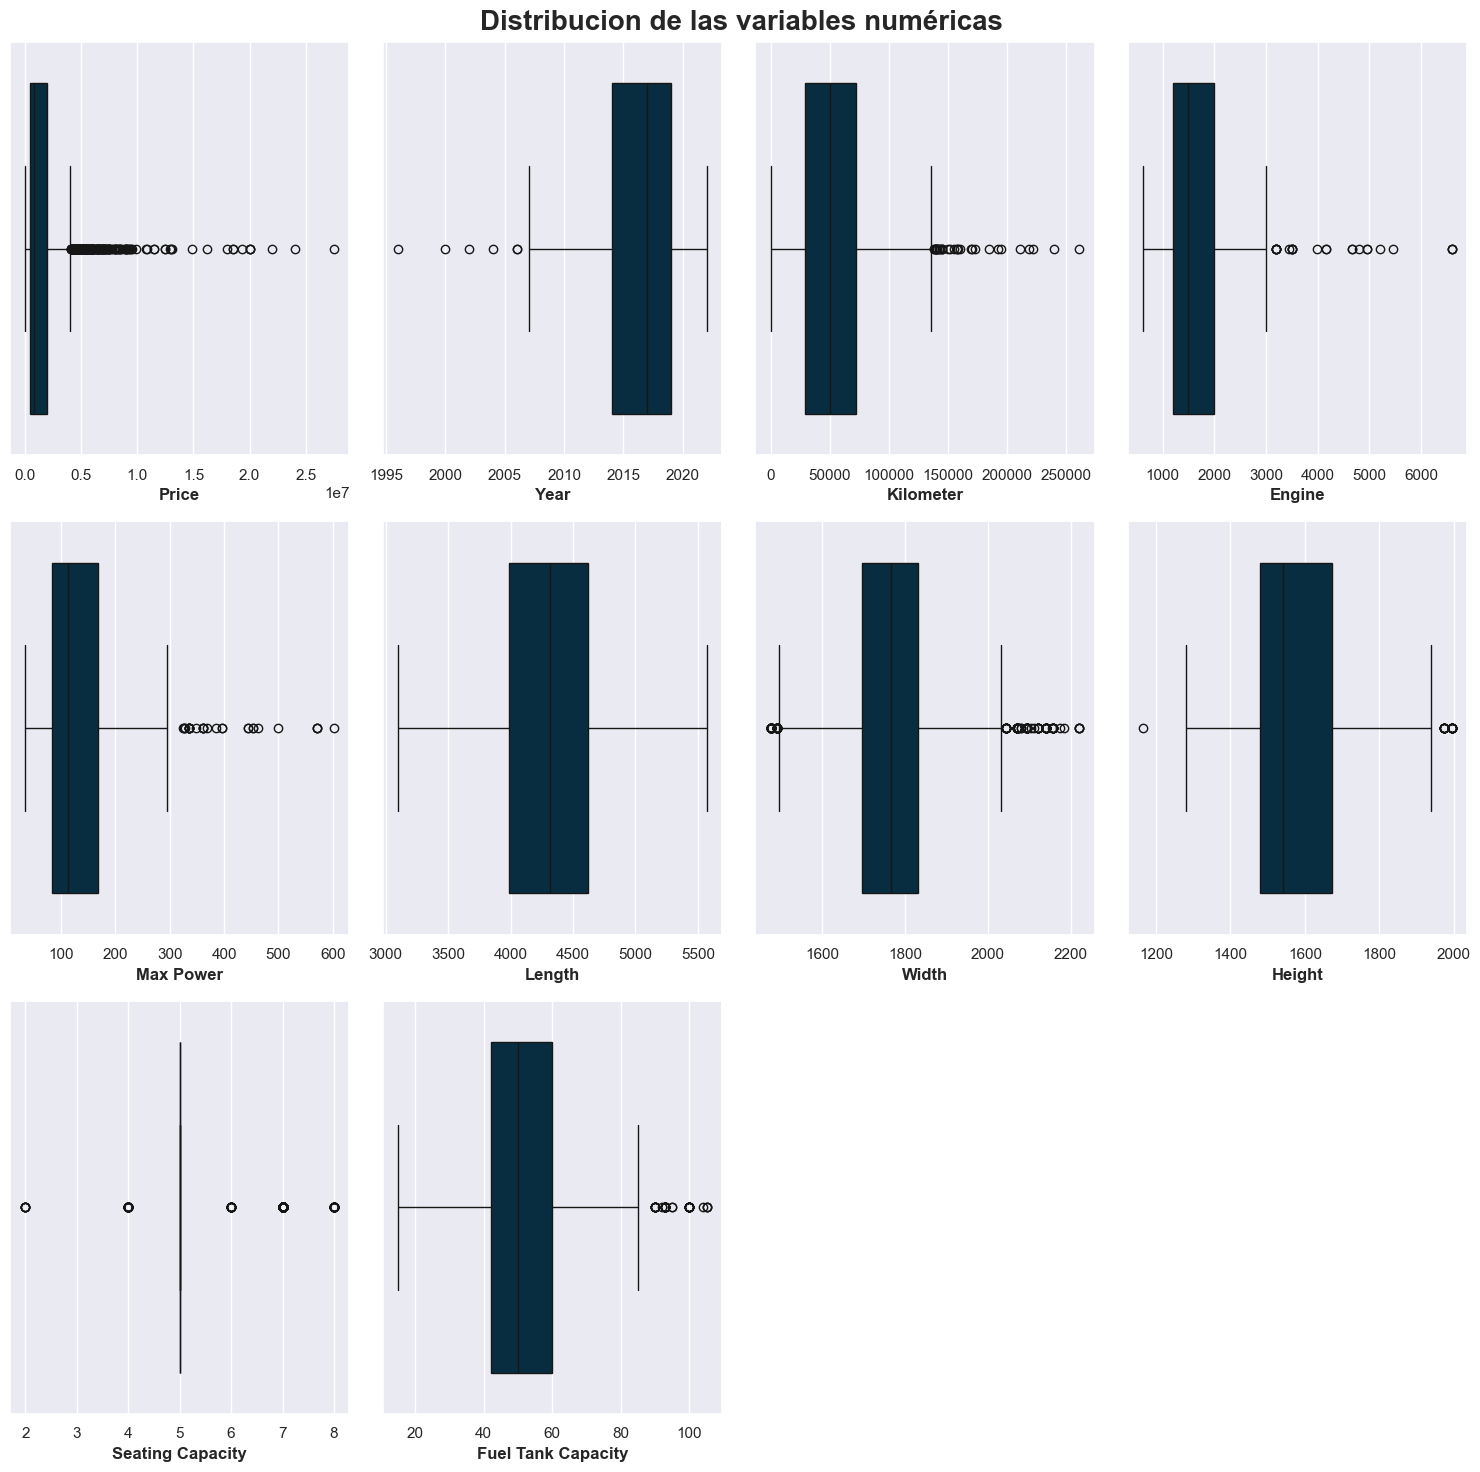

In [22]:
# Observamos nuevamente la distribución de las variables numéricas:

caracteristicas_num = data.select_dtypes(include=[np.number]).columns
num_caracteristicas_num = len(caracteristicas_num)
num_filas_num = (num_caracteristicas_num + 3) // 4  # Calcula el número de filas necesarias (redondeo hacia arriba)
num_cols_num = 4

fig, axes = plt.subplots(num_filas_num, 4, figsize=(15, 5 * num_filas_num)) # Ajusta la altura según el número de filas

# Creamos cada gráfica de caja de acuerdo a cada una de las variable:
for i in range(num_caracteristicas_num):
    fila= i //4
    columna= i % 4
    sns.boxplot(data= data, x= caracteristicas_num[i], ax= axes[fila, columna])
    axes[fila, columna].set_xlabel(caracteristicas_num[i], fontweight= "bold")
    
# Calcular cuántos subgráficos vacíos hay al final
num_total_subplots = num_filas_num * num_cols_num
num_graficos_usados = num_caracteristicas_num
num_vacios = num_total_subplots - num_graficos_usados

# Eliminar subgráficos vacíos
if num_vacios > 0:
    for i in range(num_vacios):
        fila_eliminar = (num_graficos_usados + i) // num_cols_num
        columna_eliminar = (num_graficos_usados + i) % num_cols_num
        fig.delaxes(axes[fila_eliminar, columna_eliminar])

fig.suptitle("Distribucion de las variables numéricas", fontweight= "bold", fontsize= 20)
fig.tight_layout()
plt.show()

In [23]:
# -----------------------------------
# ANÁLISIS UNIVARIABLE DE VARIABLES NUMÉRICAS
# -----------------------------------

# Resumen de datos cuantitativos:
data.describe(include="number")

,Price,Year,Kilometer,Engine,Max Power,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.054000e+03,2054.000000,2054.000000,2054.000000,2054.000000,2054.000000,2054.000000,2054.000000,2054.000000,2054.000000
mean,1.688191e+06,2016.437196,52679.253651,1672.273126,127.760808,4271.375852,1765.584226,1588.300876,5.298929,51.869669
std,2.308373e+06,3.308125,31763.205553,637.147042,63.262878,438.472068,133.816857,135.307202,0.808641,14.688547
min,4.900000e+04,1996.000000,0.000000,624.000000,35.000000,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,29000.000000,1197.000000,83.000000,3985.000000,1695.000000,1480.000000,5.000000,42.000000
50%,8.250000e+05,2017.000000,50000.000000,1497.000000,113.000000,4315.000000,1765.000000,1541.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,72000.000000,1995.000000,169.000000,4620.000000,1831.000000,1672.000000,5.000000,60.000000
max,2.750000e+07,2022.000000,261236.000000,6592.000000,602.000000,5569.000000,2220.000000,1995.000000,8.000000,105.000000


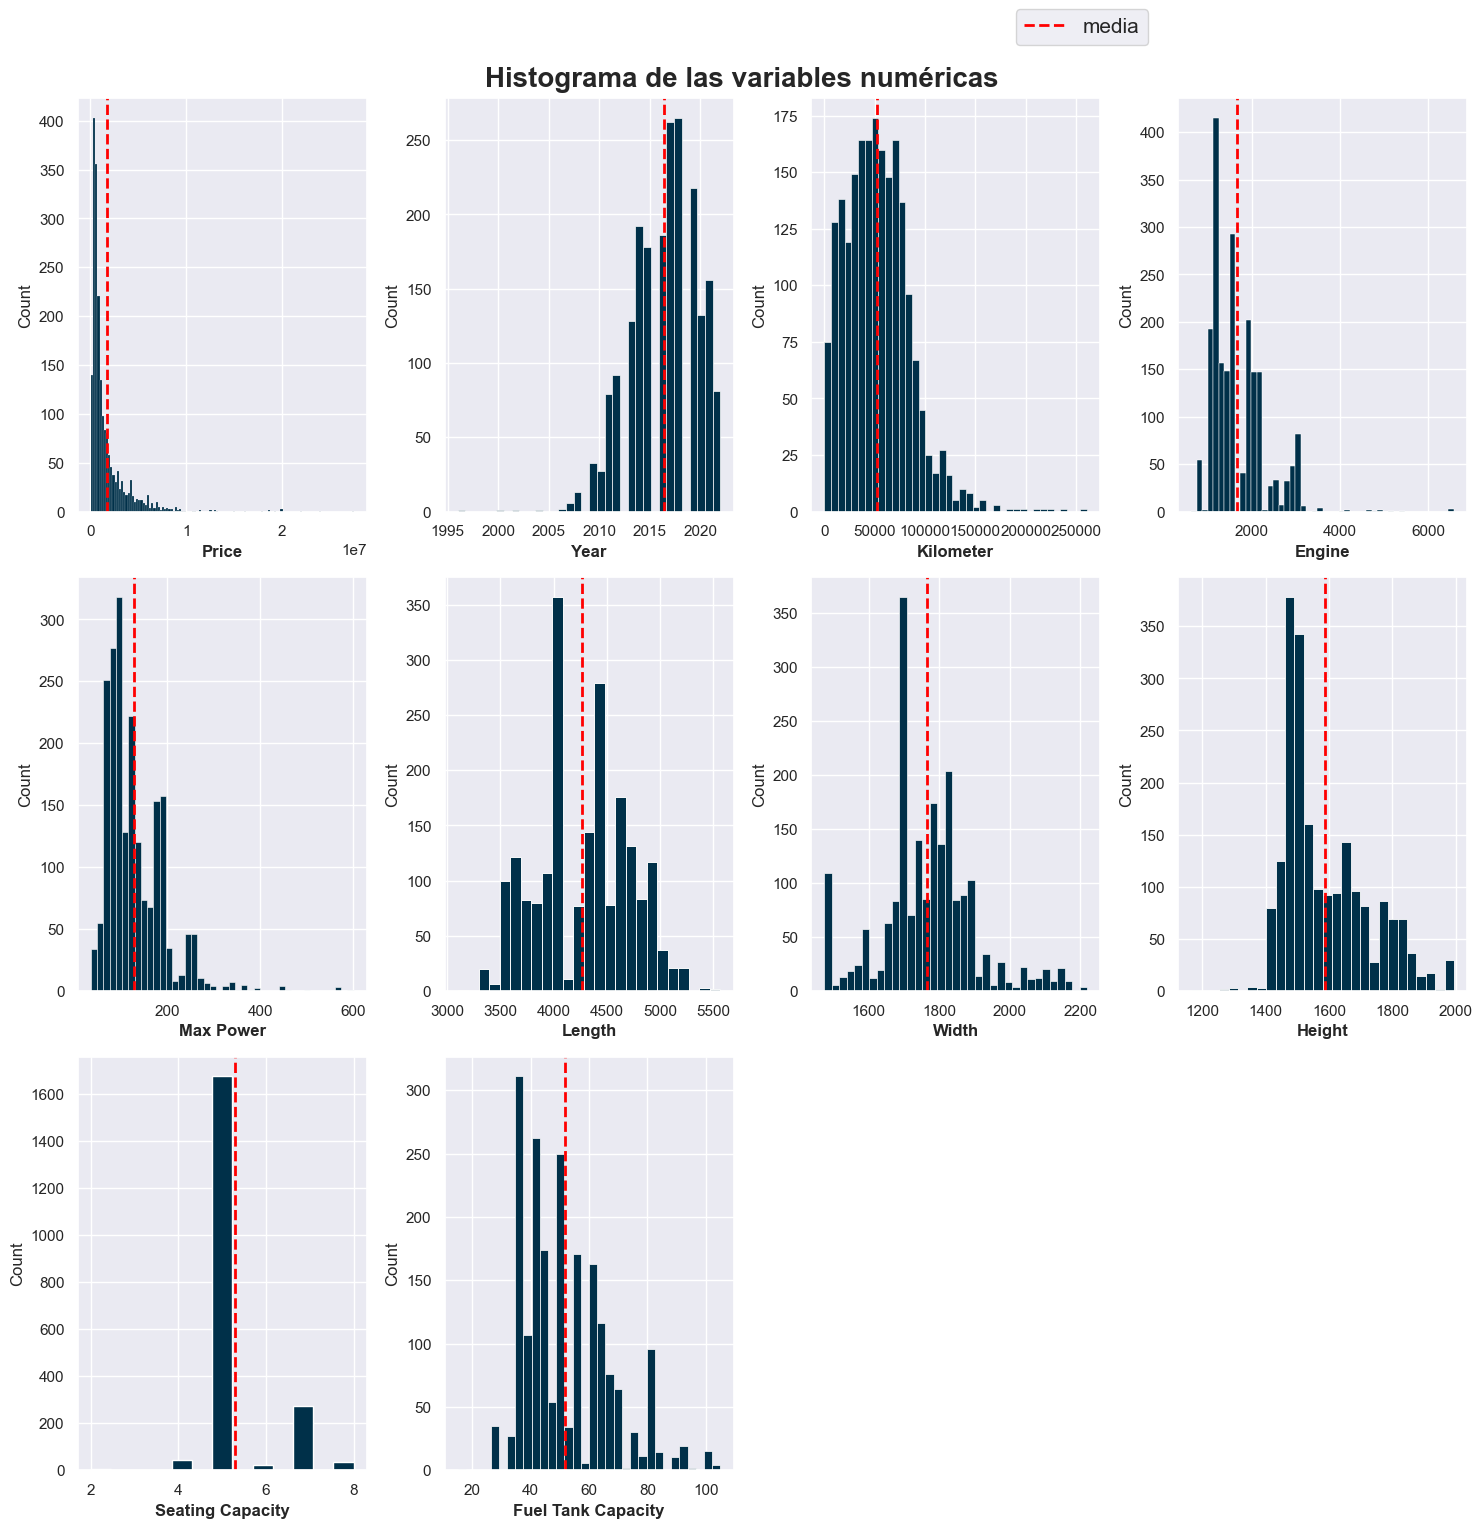

In [24]:
# Creamos la matriz de gráficas:
fig, axes = plt.subplots(num_filas_num, 4, figsize=(15, 5 * num_filas_num)) # Ajusta la altura según el número de filas

# Creamos cada gráfica de caja de acuerdo a cada una de las variable: 
for i in range(num_caracteristicas_num):
    fila= i //4
    columna= i % 4
    sns.histplot(data= data, x= caracteristicas_num[i], ax= axes[fila, columna], alpha=1)
    axes[fila, columna].axvline(x= data[caracteristicas_num[i]].mean(), linewidth= 2, color= "red", linestyle= "dashed", label= "media")
    axes[fila, columna].set_xlabel(caracteristicas_num[i], fontweight= "bold")
    axes[fila, columna].set_xlabel(caracteristicas_num[i], fontweight= "bold")

# Calcular cuántos subgráficos vacíos hay al final
num_total_subplots = num_filas_num * num_cols_num
num_graficos_usados = num_caracteristicas_num
num_vacios = num_total_subplots - num_graficos_usados

# Eliminar subgráficos vacíos
if num_vacios > 0:
    for i in range(num_vacios):
        fila_eliminar = (num_graficos_usados + i) // num_cols_num
        columna_eliminar = (num_graficos_usados + i) % num_cols_num
        fig.delaxes(axes[fila_eliminar, columna_eliminar])

fig.suptitle("Histograma de las variables numéricas", fontweight= "bold", fontsize= 20)
fig.tight_layout()
axes[0,2].legend(fontsize= 15, bbox_to_anchor= (1.2, 1.24));
plt.show()

In [25]:
# Análisis Específico de las Variables:
# • Price (Precio): La distribución está fuertemente sesgada a la derecha. La mayoría de los autos están en los rangos de precios más bajos, con una larga cola que se extiende hacia precios mucho más altos. Esto sugiere que hay menos autos caros en comparación con la cantidad de autos más asequibles. Esto es común en muchos mercados donde la mayoría de las transacciones involucran bienes de precio promedio, y los artículos de lujo son menos frecuentes.
# •	Year (Año): Distribución sesgada a la izquierda. La mayoría de los autos son de años recientes, con una fuerte disminución en la cantidad de autos más antiguos. Esto refleja la tendencia natural de mayores ventas de autos recientes en comparación con los más antiguos debido a la depreciación y los avances tecnológicos.
# •	Kilometer (Kilometraje): Distribución sesgada a la derecha. La mayoría de los autos tienen un kilometraje relativamente bajo, con una cantidad decreciente de autos con mayor kilometraje. Esto es esperado ya que los autos con un kilometraje muy alto tienden a ser menos deseables debido al desgaste.
# •	Length (Longitud): Parece ser algo normalmente distribuida, posiblemente con un ligero sesgo. Hay un pico central con una dispersión relativamente simétrica en ambos lados.
# •	Width (Ancho): Similar a Length, parece estar aproximadamente normalmente distribuida, quizás con un ligero sesgo a la derecha.
# •	Height (Altura): Parece ser multimodal o uniforme. Puede haber varios picos, o la frecuencia está algo distribuida uniformemente en todo el rango.
# •	Seating Capacity (Capacidad de Asientos): Muestra barras distintas en valores enteros específicos. La frecuencia más alta está en 5 asientos, seguida de 7 asientos.
# •	Fuel Tank Capacity (Capacidad del Tanque de Combustible): Parece ser multimodal, con picos en ciertas capacidades y valores menos frecuentes en el medio. Esto podría deberse a los tamaños de tanque estándar utilizados por diferentes fabricantes o tipos de autos.

In [26]:
# -----------------------------------
# ANÁLISIS UNIVARIABLE DE VARIABLES CATEGÓRICAS
# -----------------------------------

# Resumen de datos categóricos
data.describe(include = "object")


,Fuel Type,Transmission,Color,Owner,Seller Type,Drivetrain
count,2054,2054,2054,2054,2054,2054
unique,9,2,17,6,3,3
top,Diesel,Manual,White,First,Individual,FWD
freq,1046,1131,800,1615,1992,1463


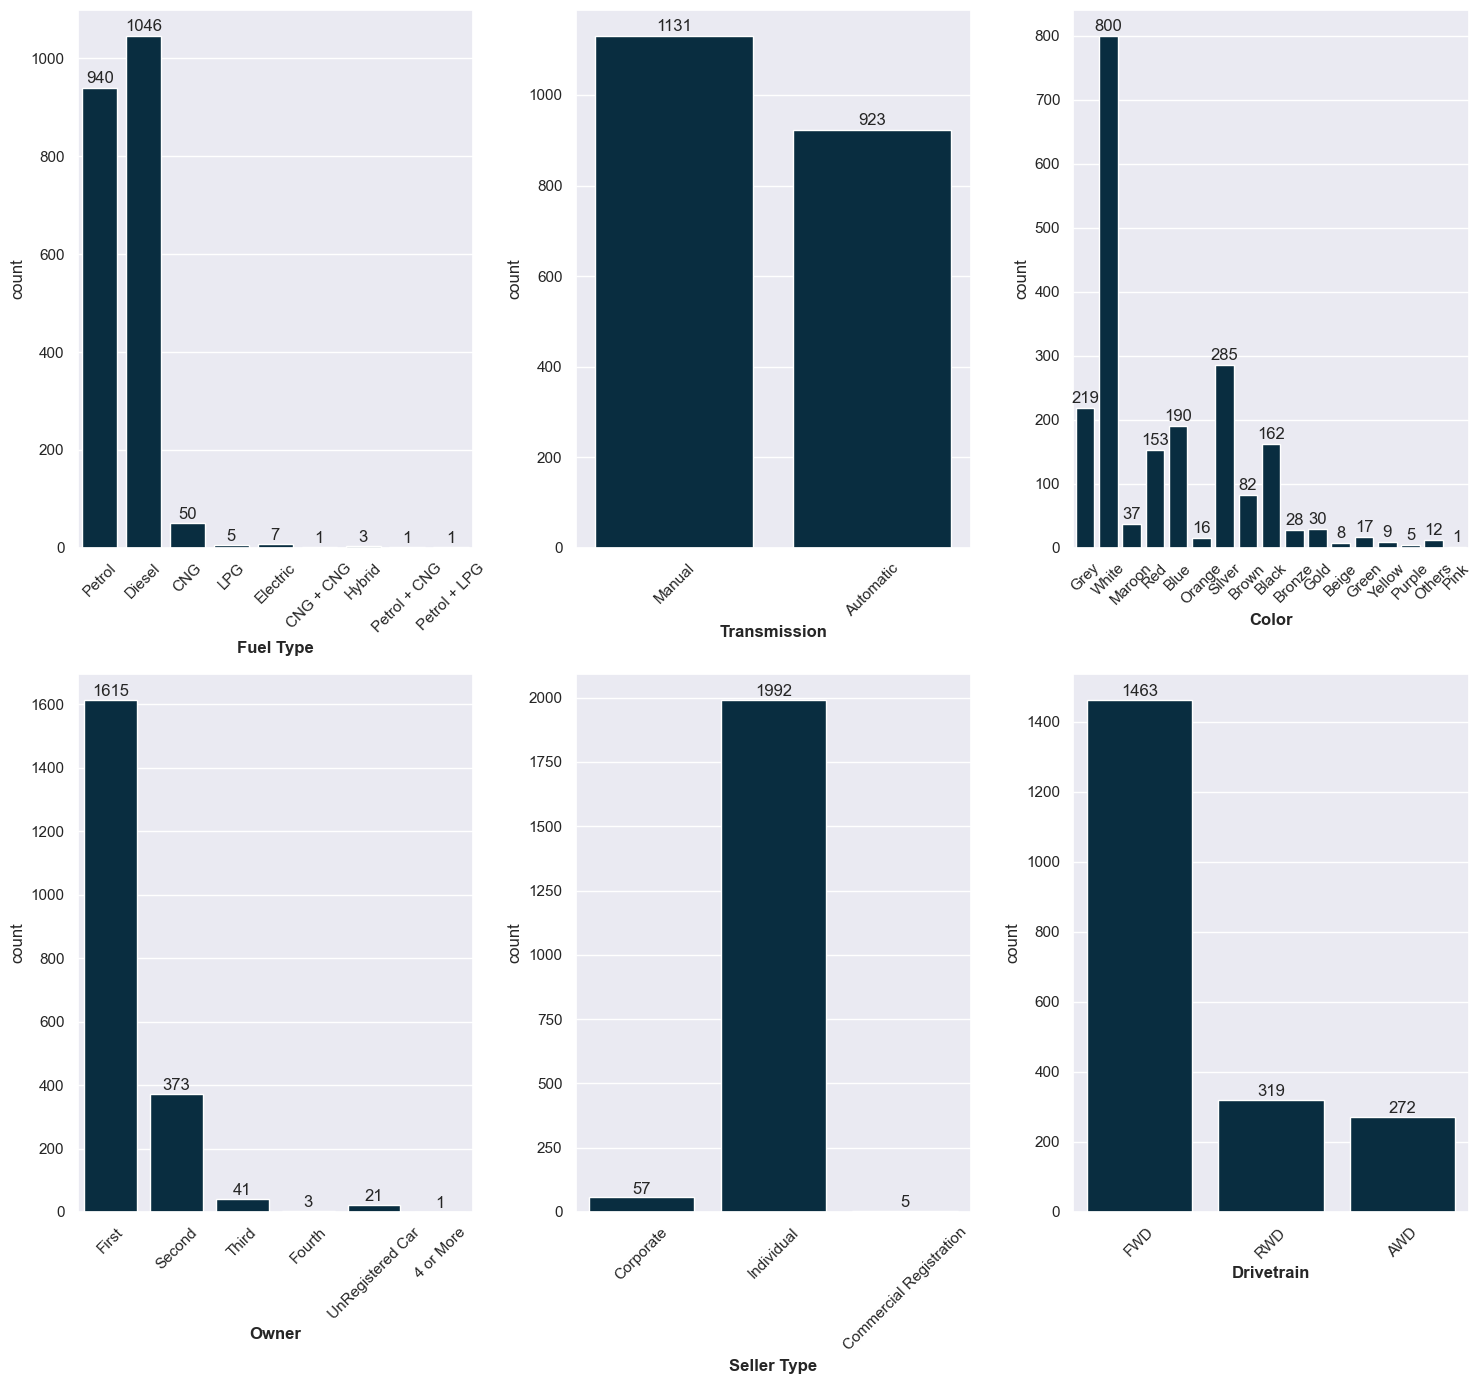

In [27]:
# Creamos la matriz de gráficas:
selected_categorical_cols = ['Fuel Type', 'Transmission', 'Owner', 'Seller Type', 'Drivetrain','Color']
caracteristicas_cat = [col for col in data.select_dtypes(include="object").columns if col in selected_categorical_cols]
num_caracteristicas_cat = len(caracteristicas_cat)
num_cols_cat = 3
num_filas_cat = (num_caracteristicas_cat + num_cols_cat - 1) // num_cols_cat  # Calcula el número de filas necesarias (redondeo hacia arriba)
ax = axes[fila, columna]

fig, axes = plt.subplots(num_filas_cat, 3, figsize=(15, 7 * num_filas_cat))  # Ajusta la altura según el número de filas

# Creamos cada gráfica de caja de acuerdo a cada una de las variable:
for i in range(num_caracteristicas_cat):
    fila= i // 3
    columna= i % 3
    ax = sns.countplot(data= data, x= caracteristicas_cat[i], ax= axes[fila, columna], alpha= 1)
    axes[fila, columna].set_xlabel(caracteristicas_cat[i], fontweight="bold")
    axes[fila, columna].tick_params(axis='x', rotation=45)
    for p in ax.patches:
        height = p.get_height()
        axes[fila, columna].text(p.get_x() + p.get_width() / 2., height + 3, f'{int(height)}', ha='center', va='bottom')

# Calcular cuántos subgráficos vacíos hay al final
num_total_subplots = num_filas_cat * num_cols_cat
num_graficos_usados = num_caracteristicas_cat
num_vacios = num_total_subplots - num_graficos_usados

# Eliminar subgráficos vacíos
if num_vacios > 0:
    for i in range(num_vacios):
        fila_eliminar = (num_graficos_usados + i) // num_cols_cat
        columna_eliminar = (num_graficos_usados + i) % num_cols_cat
        fig.delaxes(axes[fila_eliminar, columna_eliminar])
    
fig.tight_layout()
plt.show()

In [28]:
# Análisis específico de las variables: 
# • Fuel Type: La mayoría de los vehículos en el conjunto de datos funcionan con combustible Diesel, seguidos por aquellos que utilizan Gasolina (Petrol), mientras que hay muy pocos vehículos que utilizan otros tipos de combustible.
# • Transmission: Analizando la variable transmission, se observa que la mayoría de los vehículos en el conjunto de datos tienen transmisión manual.
# • Owner: En lo que respecta a la variable owner, la mayoría de los vehículos son de primer propietario, seguidos por los de segundo propietario. Hay una diferencia considerable en el número de datos para los propietarios de tercer y cuarto (y superiores) propietarios.
# • Seller Type: Predominan los vendedores individuales, seguidos por vendedores corporativos, con una presencia mínima de vehículos con registro comercial.
# • Drivetrain: La Tracción Delantera (FWD - Front-Wheel Drive) es el tipo de tren de transmisión más común, seguida de la Tracción Trasera (RWD - Rear-Wheel Drive) y la Tracción Total (AWD - All-Wheel Drive).

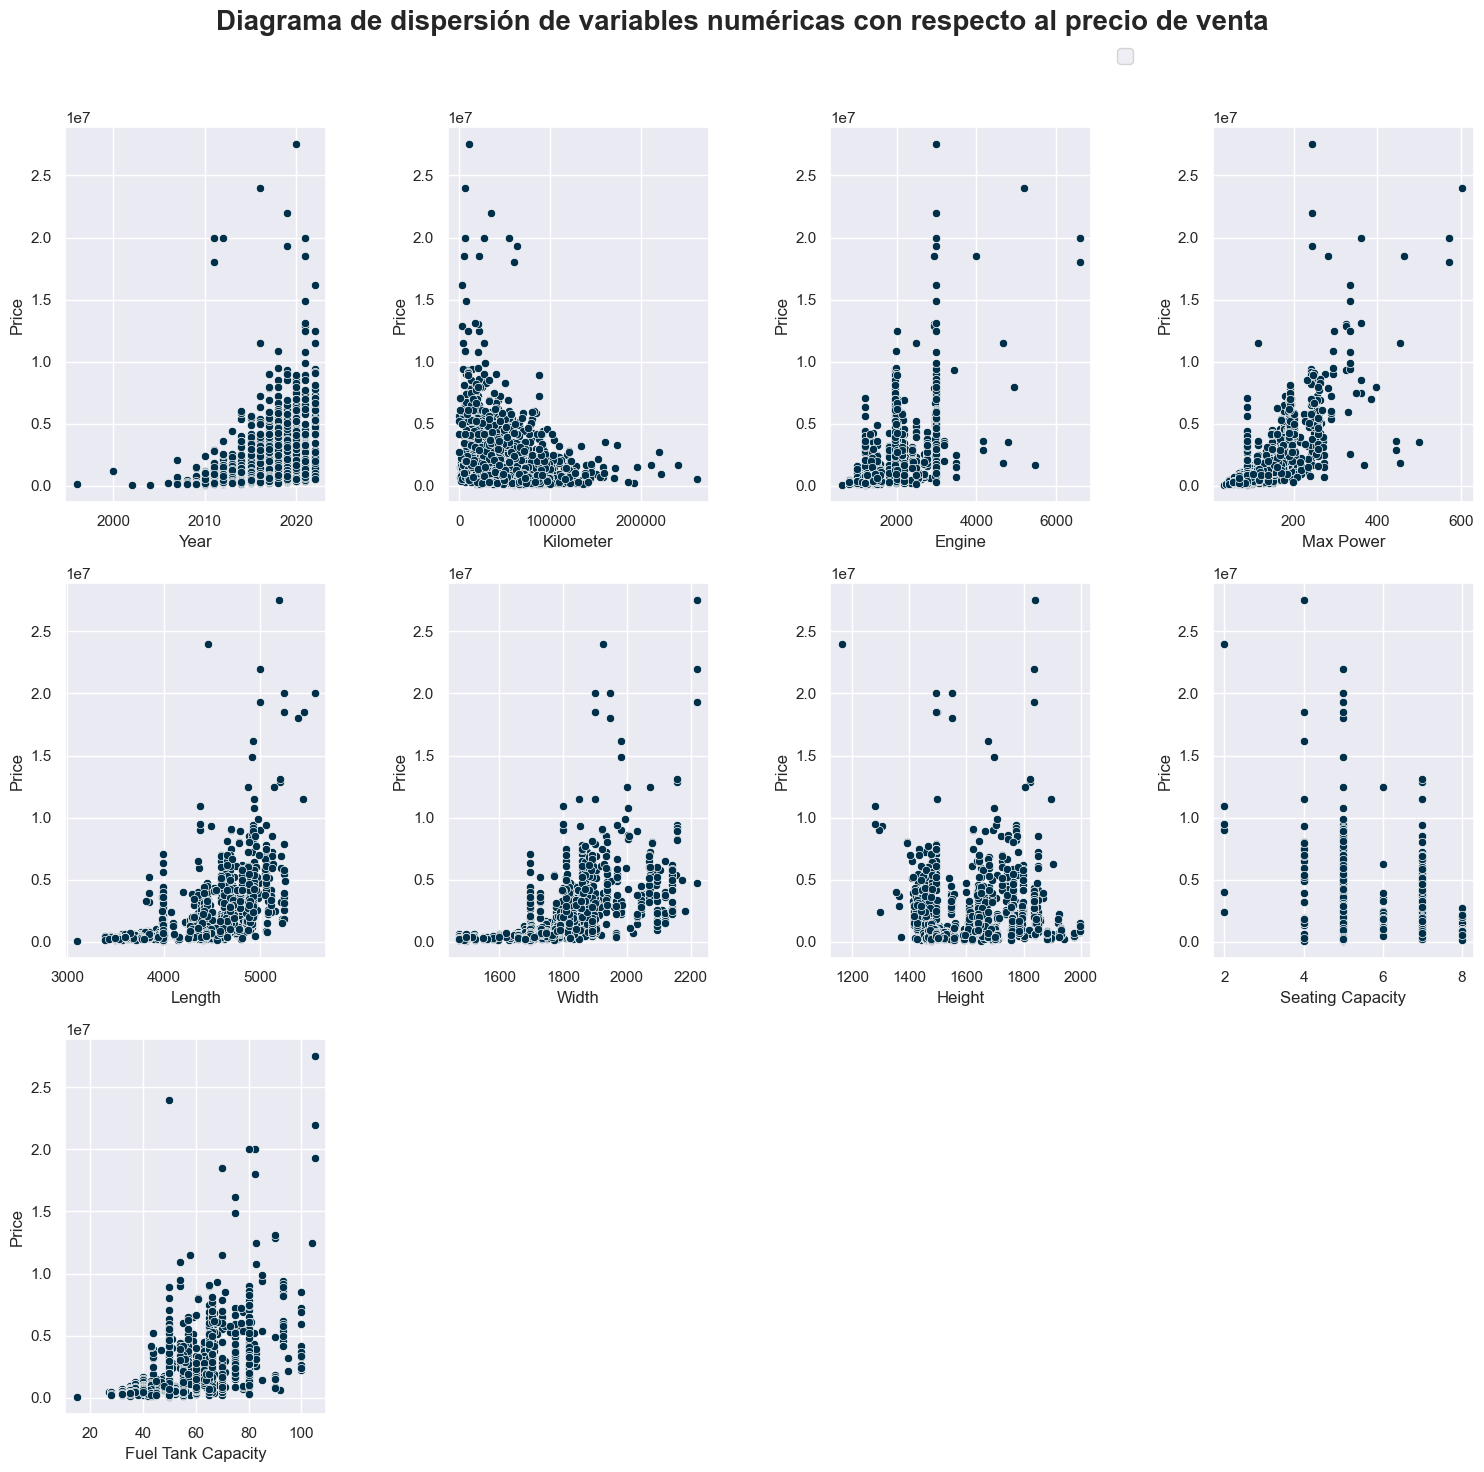

In [29]:
# -----------------------------------
# ANÁLISIS BIVARIADO DE VARIABLES NUMÉRICAS
# -----------------------------------

caracteristicas_num = data.select_dtypes(include= [np.number]).drop("Price", axis=1).columns
num_caracteristicas_num = len(caracteristicas_num)

# Creamos una matriz de gráficos:
fig, axes = plt.subplots(num_filas_num, 4, figsize=(15, 5 * num_filas_num)) # Ajusta la altura según el número de filas

# Creamos cada gráfica de caja de acuerdo a cada una de las variable: 
for i in range(num_caracteristicas_num):
    fila= i // 4
    columna= i % 4
    sns.scatterplot(ax= axes[fila, columna], data= data, x= caracteristicas_num[i], y= "Price")

# Calcular cuántos subgráficos vacíos hay al final
num_total_subplots = num_filas_num * num_cols_num
num_graficos_usados = num_caracteristicas_num
num_vacios = num_total_subplots - num_graficos_usados

# Eliminar subgráficos vacíos
if num_vacios > 0:
    for i in range(num_vacios):
        fila_eliminar = (num_graficos_usados + i) // num_cols_num
        columna_eliminar = (num_graficos_usados + i) % num_cols_num
        fig.delaxes(axes[fila_eliminar, columna_eliminar])

fig.suptitle("Diagrama de dispersión de variables numéricas con respecto al precio de venta", fontweight= "bold", fontsize= 20)
fig.tight_layout()
axes[0,2].legend(fontsize= 15, bbox_to_anchor= (1.2, 1.24));
fig.tight_layout()
plt.show()


In [30]:
# Análisis específico de las variables: 
# • Precio vs. Año: Muestra una tendencia generalmente creciente. Los autos más nuevos (años más recientes) tienden a tener precios más altos. Hay una dispersión significativa, lo que indica que otros factores también influyen en el precio. Se observa un aumento más pronunciado en los precios a partir de alrededor del año 2010.
# • Precio vs. Kilometraje: Exhibe una clara tendencia decreciente. A medida que aumenta el kilometraje, el precio del automóvil tiende a disminuir. La dispersión es mayor para kilometrajes bajos, lo que sugiere una mayor variabilidad en los precios de los autos con menos kilómetros recorridos.
# • Precio vs. Motor: No muestra una tendencia lineal clara. Hay autos con motores más pequeños y precios altos, así como autos con motores más grandes y precios bajos. Sin embargo, se pueden observar algunas concentraciones de precios en ciertos rangos de tamaño de motor.
# • Precio vs. Potencia Máxima: Indica una tendencia creciente. Los autos con mayor potencia máxima generalmente tienen precios más altos. La relación parece ser más fuerte en el rango inferior de potencia máxima.
# • Precio vs. Largo: Muestra una ligera tendencia creciente, aunque con mucha dispersión. Los autos más largos tienden a tener precios ligeramente más altos, pero el largo por sí solo no es un predictor fuerte del precio.
# • Precio vs. Ancho: Similar al largo, muestra una ligera tendencia creciente con mucha dispersión. Los autos más anchos pueden tener precios ligeramente más altos, pero no es una relación determinante.
# • Precio vs. Alto: No se observa una tendencia clara. El precio parece variar ampliamente independientemente de la altura del automóvil.
# • Precio vs. Capacidad de Asientos: Sugiere que los autos con mayor capacidad de asientos (por ejemplo, 5 o más) tienden a tener precios más altos. Los autos con 2 asientos generalmente tienen precios más bajos.
# • Precio vs. Capacidad del Tanque de Combustible: Muestra una tendencia ligeramente creciente con dispersión. Los autos con tanques de combustible más grandes pueden tener precios ligeramente más altos, pero no es una regla estricta.

# RESUMEN: 
# • El año y el kilometraje parecen ser predictores importantes del precio, con una relación positiva para el año (más nuevo = más caro) y negativa para el kilometraje (más recorrido = más barato).
# • La potencia máxima también muestra una influencia positiva en el precio.
# • El largo y el ancho pueden tener una ligera influencia positiva, pero son menos determinantes.
# • La altura no parece tener una relación clara con el precio.
# • La capacidad de asientos influye, con precios más altos para autos de mayor capacidad.
# • La capacidad del tanque de combustible muestra una ligera tendencia positiva.
# • El tamaño del motor no muestra una relación lineal simple con el precio.

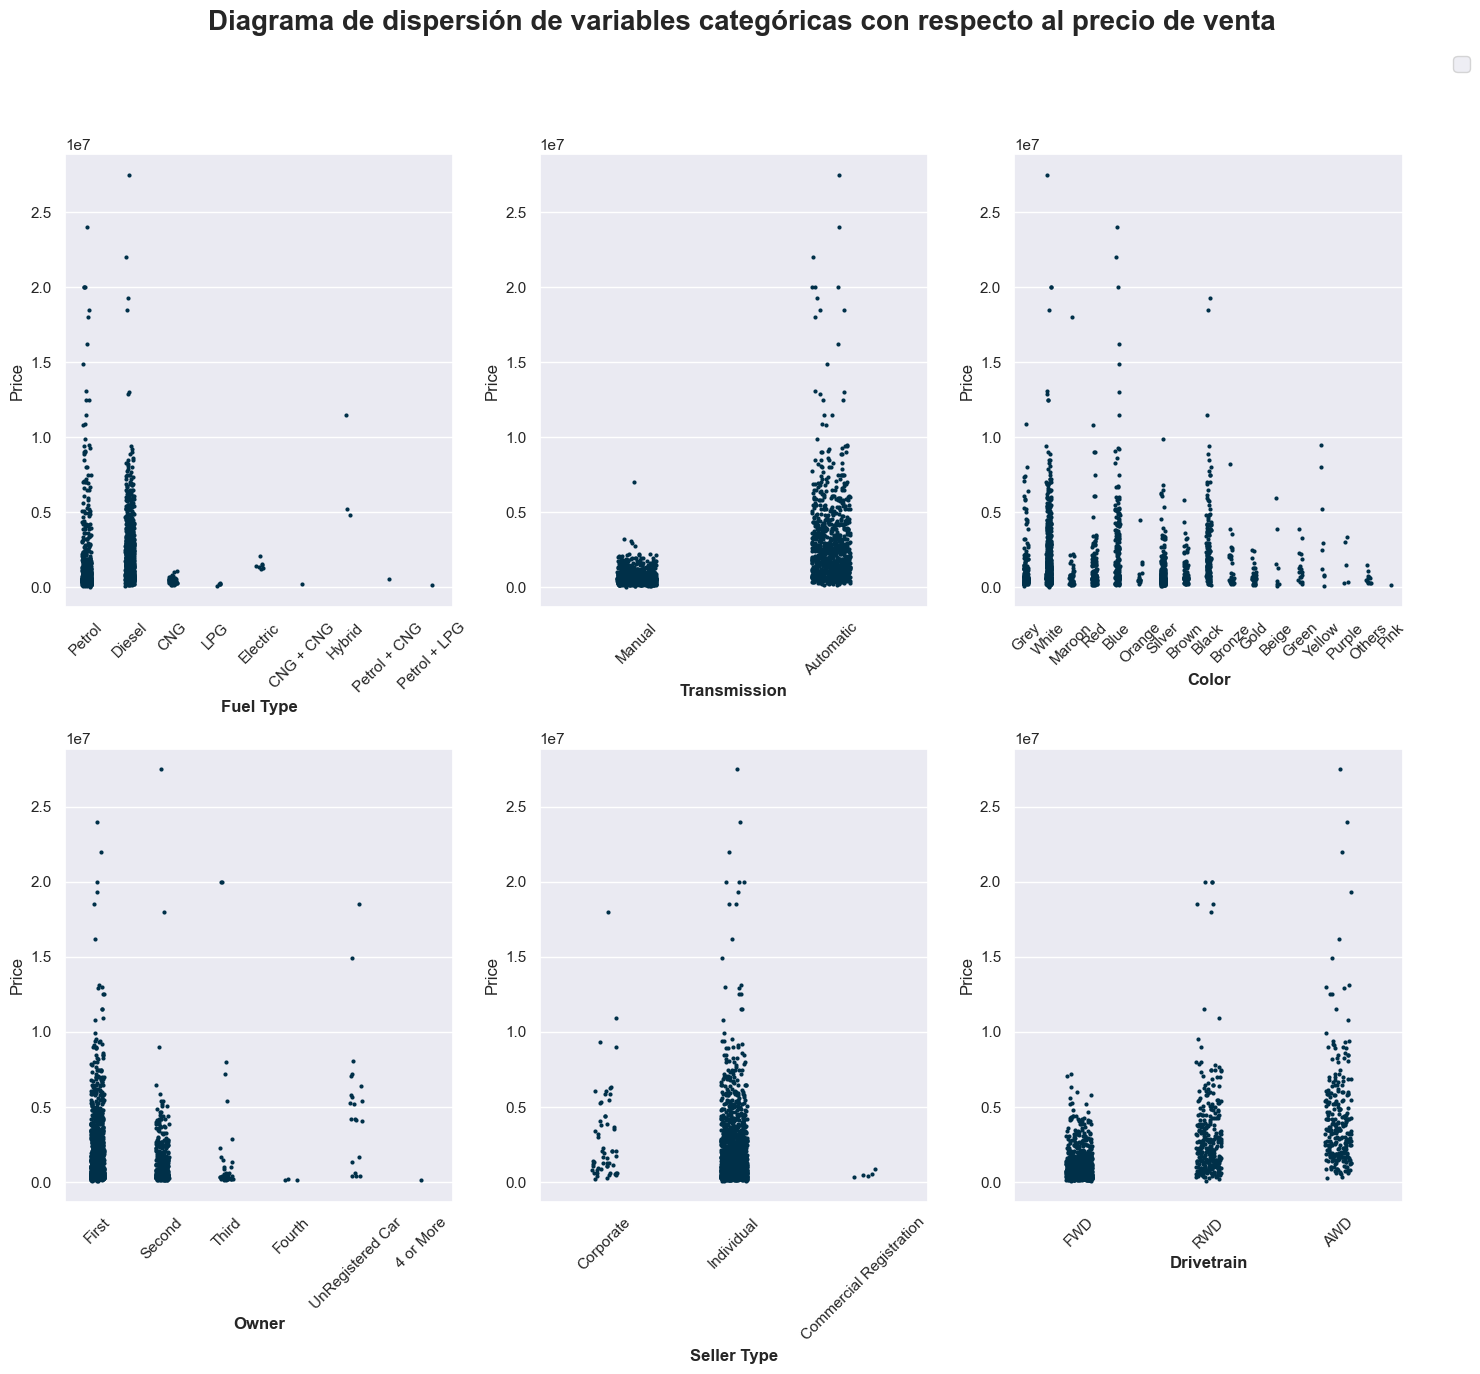

In [31]:
# -----------------------------------
# ANÁLISIS BIVARIADO DE VARIABLES CATEGÓRICAS
# -----------------------------------

selected_categorical_cols = ['Fuel Type', 'Transmission', 'Owner', 'Seller Type', 'Drivetrain','Color']
caracteristicas_cat = [col for col in data.select_dtypes(include="object").columns if col in selected_categorical_cols]
num_caracteristicas_cat = len(caracteristicas_cat)
num_cols_cat = 3
num_filas_cat = (num_caracteristicas_cat + num_cols_cat - 1) // num_cols_cat  # Calcula el número de filas necesarias (redondeo hacia arriba)
ax = axes[fila, columna]

# Creamos una matriz de gráficos:

fig, axes = plt.subplots(num_filas_cat, 3, figsize=(15, 7 * num_filas_cat))  # Ajusta la altura según el número de filas

for i in range(num_caracteristicas_cat):
    fila = i // 3
    columna =  i % 3
    sns.stripplot(ax= axes[fila, columna], data= data, x= caracteristicas_cat[i], y= "Price", s= 3)
    axes[fila, columna].set_xlabel(caracteristicas_cat[i], fontweight="bold")
    axes[fila, columna].tick_params(axis='x', rotation=45)

# Calcular cuántos subgráficos vacíos hay al final
num_total_subplots = num_filas_cat * num_cols_cat
num_graficos_usados = num_caracteristicas_cat
num_vacios = num_total_subplots - num_graficos_usados

# Eliminar subgráficos vacíos
if num_vacios > 0:
    for i in range(num_vacios):
        fila_eliminar = (num_graficos_usados + i) // num_cols_cat
        columna_eliminar = (num_graficos_usados + i) % num_cols_cat
        fig.delaxes(axes[fila_eliminar, columna_eliminar])

fig.suptitle("Diagrama de dispersión de variables categóricas con respecto al precio de venta", fontweight= "bold", fontsize= 20)
fig.tight_layout()
axes[0,2].legend(fontsize= 15, bbox_to_anchor= (1.2, 1.24));
fig.tight_layout()
plt.show()

In [32]:
# Análisis específico de las variables: 
# • Precio vs. Tipo de combustible: Los vehículos Diésel, Eléctricos e Híbridos tienden a tener precios más altos en comparación con los de Gasolina, CNG y LPG.
# • Precio vs. Tipo de transmisión: Los vehículos con transmisión Automática parecen tener un rango de precios más amplio y una tendencia hacia precios más altos que los manuales.
# • Precio vs. Número de propietarios: El precio generalmente disminuye a medida que aumenta el número de propietarios anteriores. Los vehículos de primer propietario tienen el rango de precios más amplio, incluidos los más caros.
# • Precio vs. Tipo de vendedor: Los vendedores corporativos parecen ofrecer vehículos más caros en promedio en comparación con los vendedores individuales. Los vehículos con registro comercial se encuentran principalmente en el rango de precio bajo a medio.
# • Precio vs. Tren de transmisión: Los vehículos RWD y AWD generalmente están asociados con precios más altos en comparación con los vehículos FWD.

In [33]:
# -----------------------------------
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# -----------------------------------
# Se realiza un mapeo numérico de las variables cualitativas, mediante la librería de pandas:

selected_categorical_cols = ['Fuel Type', 'Transmission', 'Owner', 'Seller Type', 'Drivetrain','Color']

data = pd.get_dummies(data, columns= selected_categorical_cols, drop_first= True)

# Identificar las columnas booleanas (las que resultaron de la codificación)
bool_cols = data.select_dtypes(include='bool').columns

# Convertir las columnas booleanas a enteros
data[bool_cols] = data[bool_cols].astype(int)

# Verificar el resultado
print(data.head())
print(data.dtypes)

     Price  Year  Kilometer  Engine  Max Power  Length   Width  Height  \
0   505000  2017      87150  1198.0       87.0  3990.0  1680.0  1505.0   
1   450000  2014      75000  1248.0       74.0  3995.0  1695.0  1555.0   
2   220000  2011      67000  1197.0       79.0  3585.0  1595.0  1550.0   
3   799000  2019      37500  1197.0       82.0  3995.0  1745.0  1510.0   
4  1950000  2018      69000  2393.0      148.0  4735.0  1830.0  1795.0   

   Seating Capacity  Fuel Tank Capacity  ...  Color_Grey  Color_Maroon  \
0               5.0                35.0  ...           1             0   
1               5.0                42.0  ...           0             0   
2               5.0                35.0  ...           0             1   
3               5.0                37.0  ...           0             0   
4               7.0                55.0  ...           1             0   

   Color_Orange  Color_Others  Color_Pink  Color_Purple  Color_Red  \
0             0             0           

In [34]:
data.info()
data.shape
data.head(11)

<class 'pandas.core.frame.DataFrame'>
Index: 2054 entries, 0 to 2058
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price                   2054 non-null   int64  
 1   Year                    2054 non-null   int64  
 2   Kilometer               2054 non-null   int64  
 3   Engine                  2054 non-null   float64
 4   Max Power               2054 non-null   float64
 5   Length                  2054 non-null   float64
 6   Width                   2054 non-null   float64
 7   Height                  2054 non-null   float64
 8   Seating Capacity        2054 non-null   float64
 9   Fuel Tank Capacity      2054 non-null   float64
 10  Fuel Type_CNG + CNG     2054 non-null   int32  
 11  Fuel Type_Diesel        2054 non-null   int32  
 12  Fuel Type_Electric      2054 non-null   int32  
 13  Fuel Type_Hybrid        2054 non-null   int32  
 14  Fuel Type_LPG           2054 non-null   int32

,Price,Year,Kilometer,Engine,Max Power,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,...,Color_Grey,Color_Maroon,Color_Orange,Color_Others,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_White,Color_Yellow
0,505000,2017,87150,1198.0,87.0,3990.0,1680.0,1505.0,5.0,35.0,...,1,0,0,0,0,0,0,0,0,0
1,450000,2014,75000,1248.0,74.0,3995.0,1695.0,1555.0,5.0,42.0,...,0,0,0,0,0,0,0,0,1,0
2,220000,2011,67000,1197.0,79.0,3585.0,1595.0,1550.0,5.0,35.0,...,0,1,0,0,0,0,0,0,0,0
3,799000,2019,37500,1197.0,82.0,3995.0,1745.0,1510.0,5.0,37.0,...,0,0,0,0,0,0,1,0,0,0
4,1950000,2018,69000,2393.0,148.0,4735.0,1830.0,1795.0,7.0,55.0,...,1,0,0,0,0,0,0,0,0,0
5,675000,2017,73315,1373.0,91.0,4490.0,1730.0,1485.0,5.0,43.0,...,1,0,0,0,0,0,0,0,0,0
6,1898999,2015,47000,1991.0,181.0,4630.0,1777.0,1432.0,5.0,50.0,...,0,0,0,0,0,0,0,0,1,0
7,2650000,2017,75000,1995.0,188.0,4439.0,1821.0,1612.0,5.0,51.0,...,0,0,0,0,0,0,0,0,1,0
8,1390000,2017,56000,1798.0,177.0,4670.0,1814.0,1476.0,5.0,50.0,...,0,0,0,0,0,0,0,0,1,0
9,575000,2015,85000,1461.0,84.0,4331.0,1822.0,1671.0,5.0,50.0,...,0,0,0,0,0,0,0,0,1,0


In [35]:
# -----------------------------------
# CONSTRUCCIÓN DEL MODELO DE REGRESIÓN LINEAL
# -----------------------------------

df = data.reset_index(drop=True).copy()

# Se definen las variables que formarán parte del conjunto de características y cuál será la variable dependiente:
X = df.drop('Price', axis=1)
y = df['Price']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (2054, 43)
Shape of y: (2054,)


In [36]:
# Dividimos nuestro conjunto en datos de entrenamiento y test:

# Utilizaremos una proporción del 75% para los datos de entrenamiento y el 25% restante para los datos de prueba para evaluar la precisión y el rendimiento del modelo.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1234, shuffle=True)
print(f"Dimensiones del X_train: {X_train.shape}")
print(f"Dimensiones del X_test: {X_test.shape}")
print(f"Dimensiones del y_train : {y_train.shape}")
print(f"Dimensiones del y_test: {y_test.shape}")

# Depuración EXTREMA de los índices
print("Antes de OLS (DESPUÉS DE LA PRIMERA DIVISIÓN):")
print("X_train.index.equals(y_train.index):", X_train.index.equals(y_train.index))
print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)
print("X_train.head():\n", X_train.head())
print("y_train.head():\n", y_train.head())

Dimensiones del X_train: (1540, 43)
Dimensiones del X_test: (514, 43)
Dimensiones del y_train : (1540,)
Dimensiones del y_test: (514,)
Antes de OLS (DESPUÉS DE LA PRIMERA DIVISIÓN):
X_train.index.equals(y_train.index): True
X_train.shape: (1540, 43)
y_train.shape: (1540,)
X_train.head():
       Year  Kilometer  Engine  Max Power  Length   Width  Height  \
1859  2019      38000  1591.0      121.0  4370.0  1700.0  1475.0   
1758  2015     138000  2179.0      138.0  4585.0  1890.0  1785.0   
1064  2017      52100   796.0       47.0  3395.0  1490.0  1475.0   
35    2018      27069  1199.0       84.0  3746.0  1647.0  1535.0   
1646  2020      12905   998.0      118.0  3995.0  1775.0  1505.0   

      Seating Capacity  Fuel Tank Capacity  Fuel Type_CNG + CNG  ...  \
1859               5.0                43.0                    0  ...   
1758               7.0                70.0                    0  ...   
1064               5.0                35.0                    0  ...   
35           

In [91]:
# Crear y entrenar el modelo

modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [92]:
# Predecir

y_pred = modelo.predict(X_test)

In [112]:
# Creamos una función donde Hallamos todas las métricas de bondad de ajuste del modelo y lo llamamos

def metricas (y_test: list, y_pred: list) -> pd.DataFrame:

    r2_score = metrics.r2_score(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred, squared= True)
    rmse = np.sqrt(mse)
    mae = metrics.mean_absolute_error(y_test, y_pred)
    m = metrics.max_error(y_test, y_pred)


# Mostramos un DataFrame donde colocamos lso datos para ese modelo de regresion
    return pd.DataFrame([r2_score, mse, rmse, mae, m], index= ["R2_score", "MSE", "RMSE", "MAE", "M"], columns= ["Modelo_reg"])

metricas(y_test, y_pred)

,Modelo_reg
R2_score,5.724692e-01
MSE,2.150477e+12
RMSE,1.466450e+06
MAE,7.495374e+05
M,2.183329e+07


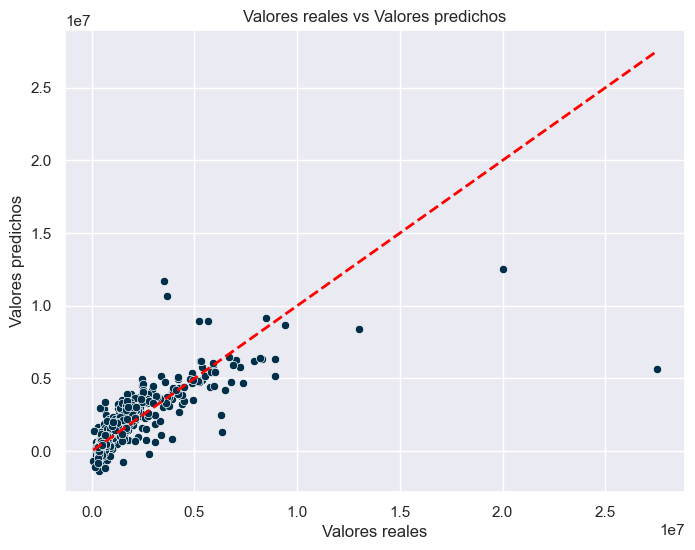

In [103]:
fig, axes = plt.subplots(nrows= 1, ncols= 1, figsize= (8, 6))
sns.scatterplot(ax= axes, x=y_test, y= y_pred)
axes.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color= "red", linewidth= 2, linestyle= "dashed")
axes.set_xlabel("Valores reales")
axes.set_ylabel("Valores predichos")
axes.set_title("Valores reales vs Valores predichos");
